# Oapi

> Dynamic OpenAPI operation client (async).

In [ ]:
#| default_exp oapi

## Imports

In [ ]:
#| export
import httpx,json,keyword
from inspect import Parameter, Signature
from urllib.parse import urlparse, urljoin, quote
from fastcore.utils import *
from fastcore.meta import delegates

from fastspec.errors import APIError
from fastspec.spec import OpSpec, SpecParser, snake, sanitize_param_name
from fastspec.transport import AsyncTransport

In [ ]:
#| hide
import yaml
from fastcore.test import *
from collections import namedtuple
from cachy.core import enable_cachy
from pyskills.core import *

In [ ]:
enable_cachy()

## Examples

In [ ]:
@patch
def read_yaml(self:Path, encoding=None, errors=None):
    "Same as `read_text` followed by `yaml.safe_load`"
    return yaml.safe_load(self.read_text(encoding=encoding, errors=errors))

Github and Stripe

In [ ]:
specs_path = Path('../specs/')

OpenAI

In [ ]:
oai_spec = dict2obj((specs_path/'openai.with-code-samples.yml').read_yaml())
oai_spec.keys(), oai_spec.servers, len(oai_spec.paths)

(dict_keys(['openapi', 'info', 'servers', 'security', 'tags', 'paths', 'webhooks', 'components', 'x-oaiMeta']),
 [{'url': 'https://api.openai.com/v1'}],
 161)

Anthropic

In [ ]:
ant_spec = dict2obj((specs_path/'anthropic.yml').read_yaml())
ant_spec.keys(), ant_spec.servers, len(ant_spec.paths)

(dict_keys(['openapi', 'info', 'paths', 'components', 'servers']),
 [{'url': 'https://api.anthropic.com'}],
 31)

Gemini

In [ ]:
gem_spec = dict2obj((specs_path/'gemini.json').read_json())
gem_spec.keys()

dict_keys(['title', 'ownerDomain', 'batchPath', 'kind', 'version_module', 'baseUrl', 'fullyEncodeReservedExpansion', 'schemas', 'protocol', 'version', 'name', 'id', 'basePath', 'mtlsRootUrl', 'parameters', 'icons', 'resources', 'description', 'rootUrl', 'documentationLink', 'ownerName', 'servicePath', 'discoveryVersion', 'canonicalName', 'revision', 'auth'])

Github and Stripe

In [ ]:
gh_spec = dict2obj((specs_path/'github.json').read_json())
stripe_spec = dict2obj((specs_path/'stripe.json').read_json())
gh_spec.keys(), stripe_spec.keys()

(dict_keys(['openapi', 'info', 'tags', 'servers', 'externalDocs', 'paths', 'x-webhooks', 'components']),
 dict_keys(['components', 'info', 'openapi', 'paths', 'security', 'servers']))

Parse specs

In [ ]:
gh_spec     = SpecParser.from_openapi(gh_spec)
stripe_spec = SpecParser.from_openapi(stripe_spec)
oai_spec = SpecParser.from_openapi(oai_spec)
ant_spec = SpecParser.from_openapi(ant_spec)
gem_spec = SpecParser.from_discovery(gem_spec)

In [ ]:
gh_spec, stripe_spec, oai_spec, ant_spec, gem_spec

(SpecParser(base_url='https://api.github.com', ops=1112),
 SpecParser(base_url='https://api.stripe.com/', ops=587),
 SpecParser(base_url='https://api.openai.com/v1', ops=241),
 SpecParser(base_url='https://api.anthropic.com', ops=47),
 SpecParser(base_url='https://generativelanguage.googleapis.com/', ops=79))

In [ ]:
op = oai_spec.ops[0]; op

<div class="prose" markdown="1">

| Field | Value |
|---|---|
| `group` | assistants |
| `name` | list_assistants |
| `path` | /assistants |
| `verb` | GET |
| `summary` | Returns a list of assistants. |
| `route_params` | [] |
| `query_params` | ['limit', 'order', 'after', 'before'] |
| `body_params` | [] |
| `file_params` | [] |
| `request_content_type` | None |
| `required_params` | set() |
| `docs_url` | None |

| Param | Type | Default | Required | Description |
|---|---|---|---|---|
| `limit` | int | 20 |  | A limit on the number of objects to be returned. Limit can range between 1 and 100, and the default is 20. |
| `order` | str | desc |  | Sort order by the `created_at` timestamp of the objects. `asc` for ascending order and `desc` for descending order. |
| `after` | str |  |  | A cursor for use in pagination. `after` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, ending with obj_foo, your subsequent call can include after=obj_foo in order to fetch the next page of the list. |
| `before` | str |  |  | A cursor for use in pagination. `before` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, starting with obj_foo, your subsequent call can include before=obj_foo in order to fetch the previous page of the list. |


</div>

### `_mk_param`

Create a function signature parameter.

In [ ]:
op.route_params, op.query_params, op.body_params, op.required_params, op.param_types, op.param_defaults, op.param_docs

([],
 ['limit', 'order', 'after', 'before'],
 [],
 set(),
 {'limit': int, 'order': str, 'after': str, 'before': str},
 {'limit': 20, 'order': 'desc'},
 {'limit': 'A limit on the number of objects to be returned. Limit can range between 1 and 100, and the default is 20.',
  'order': 'Sort order by the `created_at` timestamp of the objects. `asc` for ascending order and `desc` for descending order.',
  'after': 'A cursor for use in pagination. `after` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, ending with obj_foo, your subsequent call can include after=obj_foo in order to fetch the next page of the list.',
  'before': 'A cursor for use in pagination. `before` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, starting with obj_foo, your subsequent call can include before=obj_foo in order to fetch the previous page of the list.'})

Omit param in http request to server default when a param is not required and doesn't have a default in spec

In [ ]:
#| export
def _mk_param(name, required, anno=None, default=None):
    "Create a function signature parameter."
    anno = Parameter.empty if anno is None else anno
    if default is None: default = Parameter.empty if required else UNSET
    return Parameter(name, kind=Parameter.POSITIONAL_OR_KEYWORD, default=default, annotation=anno)

In [ ]:
params = []
for pname in op.route_params + op.query_params + op.body_params:
    params.append(_mk_param(pname, pname in op.required_params, op.param_types.get(pname), op.param_defaults.get(pname)))

In [ ]:
params

[<Parameter "limit: int = 20">,
 <Parameter "order: str = 'desc'">,
 <Parameter "after: str = UNSET">,
 <Parameter "before: str = UNSET">]

Order by required params, params without a default and params with a default:

In [ ]:
params = sorted(params, key=lambda o: {Parameter.empty:0, UNSET:1}.get(o.default, 2))

In [ ]:
params

[<Parameter "after: str = UNSET">,
 <Parameter "before: str = UNSET">,
 <Parameter "limit: int = 20">,
 <Parameter "order: str = 'desc'">]

In [ ]:
Signature(params)

<Signature (after: str = UNSET, before: str = UNSET, limit: int = 20, order: str = 'desc')>

### `_mk_sig`

Create a compact operation signature

In [ ]:
#| export
def _sort_key(o):
    if o.default is Parameter.empty: return 0
    if o.default is UNSET: return 1
    return 2

def sanitized_params(op):
    "Mapping from original param names to valid Python identifiers."
    res = {}
    for p in op.route_params + op.query_params + op.body_params + op.file_params:
        name = sanitize_param_name(p)
        if keyword.iskeyword(name): name += '_'
        res[p] = name
    return res

def mk_sig(op, sparams):
    "Create a compact operation signature from an Opop."
    params = []
    for pname, sname in sparams.items():
        params.append(_mk_param(sname, pname in op.required_params, op.param_types.get(pname), op.param_defaults.get(pname)))
    return Signature(sorted(params, key=_sort_key))

In [ ]:
sparams = sanitized_params(op); sparams

{'limit': 'limit', 'order': 'order', 'after': 'after', 'before': 'before'}

In [ ]:
sig = mk_sig(op, sparams); sig

<Signature (after: str = UNSET, before: str = UNSET, limit: int = 20, order: str = 'desc')>

### `_op_summary`

In [ ]:
#| export
def _op_summary(op):
    'Single line op summary with fallback and link rewriting'
    s = re.sub(r"\s+", " ", str(op.summary or f"{op.verb} {op.path}")).strip() or f"{op.verb} {op.path}"
    if not op.docs_url: return s
    p = urlparse(op.docs_url)
    base = f"{p.scheme}://{p.netloc}"
    return re.sub(r"\]\((/[^)]+)\)", lambda m: f"]({urljoin(base, m[1].strip())})", s)

In [ ]:
# Quick stub for testing
TestOp = namedtuple('TestOp', 'summary verb path docs_url')

# Basic summary passthrough
test_eq(_op_summary(TestOp("List models", "GET", "/models", "")), "List models")

# Fallback to verb+path when no summary
test_eq(_op_summary(TestOp("", "GET", "/models", "")), "GET /models")
test_eq(_op_summary(TestOp(None, "POST", "/chat", "")), "POST /chat")

# Whitespace cleanup
test_eq(_op_summary(TestOp("List  all\n models", "GET", "/models", "")), "List all models")

# Relative link rewriting
test_eq(_op_summary(TestOp("[details](/docs#rate)", "GET", "/x", "https://api.example.com/docs")),
        "[details](https://api.example.com/docs#rate)")

# Anchor-only link untouched
test_eq(_op_summary(TestOp("[see](#limits)", "GET", "/x", "https://api.example.com/docs")),
        "[see](#limits)")

# Absolute link untouched
test_eq(_op_summary(TestOp("[info](https://other.com/x)", "GET", "/x", "https://api.example.com/docs")),
        "[info](https://other.com/x)")

### `_op_line`

In [ ]:
#| export
def _op_line(op, sig):
    head = f"{'.'.join(snake(g) for g in listify(op.group))}.{op.name}"
    if op.docs_url: head = f"[{head}]({op.docs_url})" 
    s = f"({', '.join(sig.parameters)})"
    summ = _op_summary(op)
    return f"{head}{s}: *{summ}*"

In [ ]:
_op_line(op, sig)

'assistants.list_assistants(after, before, limit, order): *Returns a list of assistants.*'

### `_mk_doc`

Render operation docstring with summary, docs URL, and parameter hints.

In [ ]:
#| export
def mk_doc(op, sig, sparams):
    "Render operation docstring with summary, docs URL, and parameter hints."
    lines = [_op_summary(op)]
    if op.docs_url: lines.append(f"\nDocs: {op.docs_url}")
    if sig.parameters:
        lines.append("\nParameters:")
        req = set(op.required_params or [])
        # Reverse map: sparamsitized → original, for looking up docs/required
        rsparams = {v:k for k,v in sparams.items()}
        for nm,p in sig.parameters.items():
            orig = rsparams.get(nm, nm)
            r = "required" if orig in req else "optional"
            ann = '' if p.annotation is Parameter.empty else p.annotation.__name__
            desc = (op.param_docs or {}).get(orig, "")
            lines.append(f"- {nm} ({ann}, {r}){': ' + desc if desc else ''}")
    return "\n".join(lines)

https://developers.openai.com/api/reference/resources/beta/subresources/assistants/methods/list

In [ ]:
print(mk_doc(op, sig, sparams))

Returns a list of assistants.

Parameters:
- after (str, optional): A cursor for use in pagination. `after` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, ending with obj_foo, your subsequent call can include after=obj_foo in order to fetch the next page of the list.
- before (str, optional): A cursor for use in pagination. `before` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, starting with obj_foo, your subsequent call can include before=obj_foo in order to fetch the previous page of the list.
- limit (int, optional): A limit on the number of objects to be returned. Limit can range between 1 and 100, and the default is 20.
- order (str, optional): Sort order by the `created_at` timestamp of the objects. `asc` for ascending order and `desc` for descending order.


### `OpFunc`

Dynamic operation callable produced from one `OpSpec`.

In [ ]:
#| export
class OpFunc:
    def __init__(self, op_spec, client, base_url, form_encoder=None):
        store_attr()
        self.sparams       = sanitized_params(op_spec)
        self.__signature__ = mk_sig(op_spec, self.sparams)
        self.__doc__       = mk_doc(op_spec, self.__signature__, self.sparams)
        self.__name__      = op_spec.name
        self.name          = op_spec.name
        self.group         = op_spec.group
        self.path          = op_spec.path
        self.verb          = op_spec.verb
        self.route_params  = op_spec.route_params
        self.query_params  = op_spec.query_params
        self.body_params   = op_spec.body_params
        self.request_content_type = op_spec.request_content_type
        self.file_params   = op_spec.file_params
        self.summary       = op_spec.summary
        self.docs_url      = op_spec.docs_url

    def _repr_markdown_(self): return self.__doc__
    __repr__ = basic_repr()

In [ ]:
opf = OpFunc(op, None, '')

In [ ]:
opf.group, opf.name, opf.__signature__, opf.__doc__

('assistants',
 'list_assistants',
 <Signature (after: str = UNSET, before: str = UNSET, limit: int = 20, order: str = 'desc')>,
 'Returns a list of assistants.\n\nParameters:\n- after (str, optional): A cursor for use in pagination. `after` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, ending with obj_foo, your subsequent call can include after=obj_foo in order to fetch the next page of the list.\n- before (str, optional): A cursor for use in pagination. `before` is an object ID that defines your place in the list. For instance, if you make a list request and receive 100 objects, starting with obj_foo, your subsequent call can include before=obj_foo in order to fetch the previous page of the list.\n- limit (int, optional): A limit on the number of objects to be returned. Limit can range between 1 and 100, and the default is 20.\n- order (str, optional): Sort order by the `created_at` timestamp of the objects. `as

#### `_bind`

In [ ]:
#| export
@patch
def _bind(self:OpFunc, args, kwargs):
    'Prepare kwargs from args and kwargs'
    flds = [o for o in self.__signature__.parameters if o not in kwargs]
    for a,b in zip(args, flds): kwargs[b] = a
    return kwargs

In [ ]:
opf._bind(('this',), {'limit':2})

{'limit': 2, 'after': 'this'}

#### `_split`

In [ ]:
#| export
@patch
def _split(self:OpFunc, kwargs):
    "Split kwargs into route/query/body/files + control kwargs."
    stream = kwargs.get("stream", False)
    headers = kwargs.pop("_headers", {})
    # Map sanitized names back to originals
    rsparams = {v:k for k,v in self.sparams.items()}

    route, query, body, files = {}, {}, {}, {}
    for k,v in kwargs.items():
        if v is UNSET: continue
        orig = rsparams.get(k, k)
        if   orig in self.route_params: route[orig] = v
        elif orig in self.file_params:  files[orig] = v
        elif orig in self.query_params: query[orig] = v
        elif orig in self.body_params:  body[orig] = v

    query.update(kwargs.pop("_query", {}))
    body.update(kwargs.pop("_body", {}))
    if self.verb in ("GET", "DELETE", "HEAD", "OPTIONS") and not body: body = None
    return stream, headers, route, query, body, files

In [ ]:
opf._split({'limit': 2, 'after': 'this'})

(False, {}, {}, {'limit': 2, 'after': 'this'}, None, {})

#### `_path`

In [ ]:
#| export
def _path(path, route_params={}):
    "Apply route params to path template."
    if not route_params: return path
    for k,v in route_params.items():
        s = str(v)
        safe = "/" if "/" in s else ""
        path = path.replace("{" + k + "}", quote(s, safe=safe))
        path = path.replace("{+" + k + "}", quote(str(v), safe="/"))
    return re.sub(r"\{\+([^}]+)\}", lambda m: "{" + m.group(1) + "}", path)

In [ ]:
# No route params — path unchanged
test_eq(_path('/repos'), '/repos')

# Simple route param
test_eq(_path('/repos/{owner}/{repo}', {'owner': 'fastai', 'repo': 'fastcore'}), '/repos/fastai/fastcore')

# Special chars get percent-encoded
test_eq(_path('/users/{name}', {'name': 'my user'}), '/users/my%20user')

# {+param} preserves slashes
test_eq(_path('/repos/{owner}/{+path}', {'owner': 'fastai', 'path': 'src/core/utils.py'}), '/repos/fastai/src/core/utils.py')

#### `_join_url`

In [ ]:
#| export
def _join_url(base, path):
    "Join base URL and path, ensuring correct slash handling."
    return urljoin(base.rstrip("/") + "/", path.lstrip("/"))

In [ ]:
ant_spec.base_url, gem_spec.base_url

('https://api.anthropic.com', 'https://generativelanguage.googleapis.com/')

In [ ]:
ant_spec.ops[0].group, ant_spec.ops[0].name, _join_url(ant_spec.base_url, ant_spec.ops[0].path)

('messages', 'messages_post', 'https://api.anthropic.com/v1/messages')

In [ ]:
gem_spec.ops[0].group, gem_spec.ops[0].name, _join_url(gem_spec.base_url, gem_spec.ops[0].path)

(['batches'],
 'list',
 'https://generativelanguage.googleapis.com/v1beta/{+name}')

#### `__call__`

Each `OpFunc` has a signature and `__call__` to make them a proper python function. The calls are dispatched to HTTP requests via a client (`AsyncTransport`) with `.stream` and `.request` methods:

In [ ]:
#| export
@patch
def _raise_with_context(self:OpFunc, exc:Exception, *, endpoint:str, route:Optional[dict], query:Optional[dict], body:Optional[dict]):
    "Raise APIError with operation context for dynamic op calls."
    provider,model,ep = '','',''
    # TODO: Make APIError generic, users can modify/subclass it include additional info like model,provider etc..
    if isinstance(exc, (httpx.HTTPStatusError, httpx.RequestError)):
        raise exc.api_error(provider=provider, model=model) from exc
    raise exc


We can't mix `yield` and `return <value>` in the same function, that's why we have `request` and `stream` functions:

In [ ]:
#| export
@patch
@delegates(AsyncTransport.request) # files, raw
async def _request(self:OpFunc, url, *, headers=None, query=None, body=None, route=None, **kwargs):
    "Execute an HTTP request and return decoded response."
    try: return await self.client.request(self.verb, url, headers=headers, params=query, json_data=body, **kwargs)
    except Exception as e: self._raise_with_context(e, endpoint='', route=route, query=query, body=body)

@patch
@delegates(AsyncTransport.stream) # files, raw
async def _stream(self:OpFunc, url, *, headers=None, query=None, body=None, route=None, **kwargs):
    "Execute an SSE request yielding parsed JSON events."
    try:
        async for ev in self.client.stream(self.verb, url, headers=headers, params=query, json_data=body, **kwargs): yield ev
    except Exception as e: self._raise_with_context(e, endpoint='', route=route, query=query, body=body)

In [ ]:
#| export
@patch
async def __call__(self:OpFunc, *args, **kwargs):
    stream, headers, route, query, body, files = self._split(self._bind(args, kwargs))
    url = _join_url(self.base_url, _path(self.path, route_params=route))
    if files: 
        kw = dict(body=None, files=files, data=self.form_encoder(body) or None)
    elif self.request_content_type == "application/x-www-form-urlencoded": 
        kw = dict(body=None, data=self.form_encoder(body))
    else: kw = dict(body=body)
    if stream: return dict2obj(self._stream(url, headers=headers, query=query, route=route, **kw))
    return dict2obj(await self._request(url, headers=headers, query=query, route=route, **kw))

In [ ]:
transport_cli = AsyncTransport(base_headers={"x-api-key": os.environ['ANTHROPIC_API_KEY'],"anthropic-version": "2023-06-01"})
opf = OpFunc(ant_spec.ops[0], transport_cli, ant_spec.base_url)

A simple Anthropic request:

In [ ]:
resp = await opf(model="claude-sonnet-4-20250514", max_tokens=64, messages=[{"role":"user","content":"Hi!"}])
resp

{'model': 'claude-sonnet-4-20250514',
 'id': 'msg_01Dz6LicJ7EWU7rKfmLAgaF8',
 'type': 'message',
 'role': 'assistant',
 'content': [{'type': 'text',
   'text': 'Hello! How are you doing today? Is there anything I can help you with?'}],
 'stop_reason': 'end_turn',
 'stop_sequence': None,
 'stop_details': None,
 'usage': {'input_tokens': 9,
  'cache_creation_input_tokens': 0,
  'cache_read_input_tokens': 0,
  'cache_creation': {'ephemeral_5m_input_tokens': 0,
   'ephemeral_1h_input_tokens': 0},
  'output_tokens': 20,
  'service_tier': 'standard',
  'inference_geo': 'not_available'}}

With streaming:

In [ ]:
resp = await opf(model="claude-sonnet-4-20250514", max_tokens=64, messages=[{"role":"user","content":"Hi!"}], stream=True)
async for ev in resp: print(ev)

{'type': 'message_start', 'message': {'model': 'claude-sonnet-4-20250514', 'id': 'msg_01A5mggxPb3sKktegqrZy2Eh', 'type': 'message', 'role': 'assistant', 'content': [], 'stop_reason': None, 'stop_sequence': None, 'stop_details': None, 'usage': {'input_tokens': 9, 'cache_creation_input_tokens': 0, 'cache_read_input_tokens': 0, 'cache_creation': {'ephemeral_5m_input_tokens': 0, 'ephemeral_1h_input_tokens': 0}, 'output_tokens': 4, 'service_tier': 'standard', 'inference_geo': 'not_available'}}}
{'type': 'content_block_start', 'index': 0, 'content_block': {'type': 'text', 'text': ''}}
{'type': 'ping'}
{'type': 'content_block_delta', 'index': 0, 'delta': {'type': 'text_delta', 'text': 'Hello! How are'}}
{'type': 'content_block_delta', 'index': 0, 'delta': {'type': 'text_delta', 'text': ' you doing today? Is there anything I can help you with?'}}
{'type': 'content_block_stop', 'index': 0}
{'type': 'message_delta', 'delta': {'stop_reason': 'end_turn', 'stop_sequence': None, 'stop_details': None

With route params:

In [ ]:
gh_op_spec = L(gh_spec.ops).filter(lambda o: o.path=='/repos/{owner}/{repo}')[0]; gh_op_spec

<div class="prose" markdown="1">

| Field | Value |
|---|---|
| `group` | repos |
| `name` | get |
| `path` | /repos/{owner}/{repo} |
| `verb` | GET |
| `summary` | Get a repository |
| `route_params` | ['owner', 'repo'] |
| `query_params` | [] |
| `body_params` | [] |
| `file_params` | [] |
| `request_content_type` | None |
| `required_params` | {'owner', 'repo'} |
| `docs_url` | https://docs.github.com/organizations/managing-peoples-access-to-your-organization-with-roles/managing-security-managers-in-your-organization |

| Param | Type | Default | Required | Description |
|---|---|---|---|---|
| `owner` | str |  | ✓ | The account owner of the repository. The name is not case sensitive. |
| `repo` | str |  | ✓ | The name of the repository without the `.git` extension. The name is not case sensitive. |


</div>

In [ ]:
gh_cli = AsyncTransport(base_headers={"Authorization": f"token {os.environ['GITHUB_TOKEN']}"})
gh_opf = OpFunc(gh_op_spec, gh_cli, gh_spec.base_url)
resp = await gh_opf(owner="AnswerDotAI", repo="fastllm")
resp['html_url'], resp['private']

('https://github.com/AnswerDotAI/fastllm', True)

### `OpGroup`

Simple namespace for grouped operations.

In [ ]:
#| export
class OpGroup:
    "Simple namespace for grouped operations."
    def __init__(self, name: str, ops: Iterable[OpFunc]):
        self.name,self.ops = name,list(ops)
        repr_md = []
        for op in self.ops: 
            setattr(self, op.name, op)
            if hasattr(op, '__signature__'): repr_md.append(f"- {_op_line(op, op.__signature__)}")
        self.__doc__ = "\n".join(repr_md)
    
    def _repr_markdown_(self): return self.__doc__

#### `_build_groups`

In [ ]:
#| export
def _build_groups(ops:List[OpFunc]):
    "Build nested op group tree from ops."
    root = {}
    for op in ops:
        g = [snake(p) for p in listify(op.group)]
        node = root
        for part in g[:-1]: node = node.setdefault(part, {})
        node.setdefault(g[-1], {}).setdefault('_ops', []).append(op)

    def _mk(name, d):
        grp = OpGroup(name, d.pop('_ops', []))
        for k,v in d.items(): setattr(grp, k, _mk(k, v))
        return grp

    return {k: _mk(k, v) for k,v in root.items()}

In [ ]:
TestOp = namedtuple('TestOp', 'group name op_spec docs_url')

ops = [
    TestOp("repos", "get", "", ""),
    TestOp("repos", "list", "", ""),
    TestOp(["tuned_models"], "get", "", ""),
    TestOp(["tuned_models", "permissions"], "list", "", ""),
    TestOp(["tuned_models", "permissions"], "delete", "", ""),
]

In [ ]:
op_groups = _build_groups(ops); op_groups

{'repos': <__main__.OpGroup>,
 'tuned_models': <__main__.OpGroup>}

Nested groups with attribute chaining:

In [ ]:
test_eq(isinstance(op_groups['tuned_models'].permissions, OpGroup), True)

In [ ]:
op_groups['tuned_models'].get, op_groups['tuned_models'].permissions.delete, op_groups['tuned_models'].permissions.list

(TestOp(group=['tuned_models'], name='get', op_spec='', docs_url=''),
 TestOp(group=['tuned_models', 'permissions'], name='delete', op_spec='', docs_url=''),
 TestOp(group=['tuned_models', 'permissions'], name='list', op_spec='', docs_url=''))

In [ ]:
op_groups['repos'].get, op_groups['repos'].list

(TestOp(group='repos', name='get', op_spec='', docs_url=''),
 TestOp(group='repos', name='list', op_spec='', docs_url=''))

In [ ]:
ops = [OpFunc(op, None, gem_spec.base_url) for op in gem_spec.ops]

In [ ]:
ops[:2]

[OpFunc(op_spec=OpSpec(group=['batches'], name='list', path='v1beta/{+name}', verb='GET', summary="Lists operations that match the specified filter in the request. If the server doesn't support this method, it returns `UNIMPLEMENTED`.", route_params=['name'], query_params=['filter', 'pageSize', 'pageToken', 'returnPartialSuccess'], body_params=[], file_params=[], request_content_type='', required_params={'name'}, param_types={'name': <class 'str'>, 'filter': <class 'str'>, 'pageSize': <class 'int'>, 'pageToken': <class 'str'>, 'returnPartialSuccess': <class 'bool'>}, param_defaults={}, param_docs={'name': "The name of the operation's parent resource.", 'filter': 'The standard list filter.', 'pageSize': 'The standard list page size.', 'pageToken': 'The standard list page token.', 'returnPartialSuccess': 'When set to `true`, operations that are reachable are returned as normal, and those that are unreachable are returned in the ListOperationsResponse.unreachable field. This can only be `

In [ ]:
gem_groups = _build_groups(ops)

In [ ]:
len(gem_groups)

10

In [ ]:
gem_groups.keys()

dict_keys(['batches', 'models', 'tuned_models', 'dynamic', 'cached_contents', 'media', 'files', 'generated_files', 'file_search_stores', 'corpora'])

In [ ]:
gem_groups['tuned_models'].permissions.create

<div class="prose" markdown="1">

Create a permission to a specific resource.

Parameters:
- parent (str, required): Required. The parent resource of the `Permission`. Formats: `tunedModels/{tuned_model}` `corpora/{corpus}`
- role (str, required): Required. The role granted by this permission.
- name (str, optional): Output only. Identifier. The permission name. A unique name will be generated on create. Examples: tunedModels/{tuned_model}/permissions/{permission} corpora/{corpus}/permissions/{permission} Output only.
- grantee_type (str, optional): Optional. Immutable. The type of the grantee.
- email_address (str, optional): Optional. Immutable. The email address of the user of group which this permission refers. Field is not set when permission's grantee type is EVERYONE.

</div>

### `OpenAPIClient`

Runtime dynamic API client built from operation metadata.

> The one exception is **file uploads** — the spec *does* indicate this via `multipart/form-data` content type, so `_files`/`_data` could potentially be inferred.

This is good we should do that.

> But `_stream`, `_raw`, `_headers`, `_query`, `_body`, `_endpoint` — these are all **consumer-level transport concerns** that have no representation in the spec.

- Does it ever happen that an api endpoint supports streaming, e.g. we need to use `self.client.stream` but doesn't expose a param for that? Maybe we can automatically dispatch to `astream` when `stream=True` is set in args/kwargs?

- `_raw`, `_headers`, `_query`, `_body`, `_endpoint`, why do we need these please check the fastllm library code to make the connections.



In [ ]:
#| export
class OpenAPIClient:
    "Async client built from OpenAPI operation metadata."
    def __init__(self, spec, *, headers=None, timeout=60.0, form_encoder=None):
        self.transport = AsyncTransport(timeout=timeout, base_headers=headers)
        enc = ifnone(form_encoder, noop)
        self.ops = [OpFunc(o, self.transport, spec.base_url, enc) for o in spec.ops]
        self.func_dict = {f"{o.path}:{o.verb.upper()}": o for o in self.ops}
        self.groups = _build_groups(self.ops)
        for k,v in self.groups.items(): setattr(self, k, v)

##### Gemini Client:

In [ ]:
gem_cli = OpenAPIClient(gem_spec)

Group docs:

In [ ]:
print(doc(gem_cli.models))

- models.generate_content(model, contents, system_instruction, tools, tool_config, safety_settings, generation_config, cached_content, service_tier, store): *Generates a model response given an input `GenerateContentRequest`. Refer to the [text generation guide](https://ai.google.dev/gemini-api/docs/text-generation) for detailed usage information. Input capabilities differ between models, including tuned models. Refer to the [model guide](https://ai.google.dev/gemini-api/docs/models/gemini) and [tuning guide](https://ai.google.dev/gemini-api/docs/model-tuning) for details.*
- models.generate_answer(model, contents, answer_style, inline_passages, semantic_retriever, safety_settings, temperature): *Generates a grounded answer from the model given an input `GenerateAnswerRequest`.*
- models.stream_generate_content(model, contents, system_instruction, tools, tool_config, safety_settings, generation_config, cached_content, service_tier, store): *Generates a [streamed response](https://ai.go

A single Op doc:

In [ ]:
print(doc(gem_cli.models.generate_content))

Generates a model response given an input `GenerateContentRequest`. Refer to the [text generation guide](https://ai.google.dev/gemini-api/docs/text-generation) for detailed usage information. Input capabilities differ between models, including tuned models. Refer to the [model guide](https://ai.google.dev/gemini-api/docs/models/gemini) and [tuning guide](https://ai.google.dev/gemini-api/docs/model-tuning) for details.

Parameters:
- model (str, required): Required. The name of the `Model` to use for generating the completion. Format: `models/{model}`.
- contents (list, required): Required. The content of the current conversation with the model. For single-turn queries, this is a single instance. For multi-turn queries like [chat](https://ai.google.dev/gemini-api/docs/text-generation#chat), this is a repeated field that contains the conversation history and the latest request.
- system_instruction (dict, optional): Optional. Developer set [system instruction(s)](https://ai.google.dev/ge

##### Anthropic Client:

In [ ]:
cli = OpenAPIClient(ant_spec)

In [ ]:
cli.messages

<div class="prose" markdown="1">

- [messages.messages_post](https://docs.claude.com/en/docs/initial-setup)(model, messages, max_tokens, cache_control, container, inference_geo, metadata, output_config, service_tier, stop_sequences, stream, system, temperature, thinking, tool_choice, tools, top_k, top_p): *Create a Message*
- [messages.message_batches_post](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(requests): *Create a Message Batch*
- [messages.message_batches_list](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(before_id, after_id, limit): *List Message Batches*
- [messages.message_batches_retrieve](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve a Message Batch*
- [messages.message_batches_delete](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Delete a Message Batch*
- [messages.message_batches_cancel](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Cancel a Message Batch*
- [messages.message_batches_results](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve Message Batch results*
- [messages.messages_count_tokens_post](https://docs.claude.com/en/docs/build-with-claude/token-counting)(messages, model, cache_control, output_config, system, thinking, tool_choice, tools): *Count tokens in a Message*
- [messages.beta_message_batches_post](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(requests): *Create a Message Batch*
- [messages.beta_message_batches_list](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(before_id, after_id, limit): *List Message Batches*
- [messages.beta_message_batches_retrieve](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve a Message Batch*
- [messages.beta_message_batches_delete](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Delete a Message Batch*
- [messages.beta_message_batches_cancel](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Cancel a Message Batch*
- [messages.beta_message_batches_results](https://docs.claude.com/en/docs/build-with-claude/batch-processing)(message_batch_id): *Retrieve Message Batch results*
- [messages.beta_messages_count_tokens_post](https://docs.claude.com/en/docs/build-with-claude/token-counting)(messages, model, cache_control, context_management, mcp_servers, output_config, output_format, speed, system, thinking, tool_choice, tools): *Count tokens in a Message*

</div>

##### OpenAI Client:

In [ ]:
cli = OpenAPIClient(oai_spec)

In [ ]:
cli.responses.create_response

<div class="prose" markdown="1">

Creates a model response. Provide [text](/docs/guides/text) or [image](/docs/guides/images) inputs to generate [text](/docs/guides/text) or [JSON](/docs/guides/structured-outputs) outputs. Have the model call your own [custom code](/docs/guides/function-calling) or use built-in [tools](/docs/guides/tools) like [web search](/docs/guides/tools-web-search) or [file search](/docs/guides/tools-file-search) to use your own data as input for the model's response.

Parameters:
- metadata (dict, optional): Set of 16 key-value pairs that can be attached to an object. This can be useful for storing additional information about the object in a structured format, and querying for objects via API or the dashboard. Keys are strings with a maximum length of 64 characters. Values are strings with a maximum length of 512 characters.
- top_logprobs (int, optional): An integer between 0 and 20 specifying the number of most likely tokens to return at each token position, each with an associated log probability.
- user (str, optional): This field is being replaced by `safety_identifier` and `prompt_cache_key`. Use `prompt_cache_key` instead to maintain caching optimizations. A stable identifier for your end-users. Used to boost cache hit rates by better bucketing similar requests and to help OpenAI detect and prevent abuse. [Learn more](/docs/guides/safety-best-practices#safety-identifiers).
- safety_identifier (str, optional): A stable identifier used to help detect users of your application that may be violating OpenAI's usage policies. The IDs should be a string that uniquely identifies each user, with a maximum length of 64 characters. We recommend hashing their username or email address, in order to avoid sending us any identifying information. [Learn more](/docs/guides/safety-best-practices#safety-identifiers).
- prompt_cache_key (str, optional): Used by OpenAI to cache responses for similar requests to optimize your cache hit rates. Replaces the `user` field. [Learn more](/docs/guides/prompt-caching).
- prompt_cache_retention (str, optional): The retention policy for the prompt cache. Set to `24h` to enable extended prompt caching, which keeps cached prefixes active for longer, up to a maximum of 24 hours. [Learn more](/docs/guides/prompt-caching#prompt-cache-retention).
- previous_response_id (str, optional): The unique ID of the previous response to the model. Use this to create multi-turn conversations. Learn more about [conversation state](/docs/guides/conversation-state). Cannot be used in conjunction with `conversation`.
- model (str, optional): Model ID used to generate the response, like `gpt-4o` or `o3`. OpenAI offers a wide range of models with different capabilities, performance characteristics, and price points. Refer to the [model guide](/docs/models) to browse and compare available models.
- reasoning (dict, optional): **gpt-5 and o-series models only** Configuration options for [reasoning models](https://platform.openai.com/docs/guides/reasoning).
- max_output_tokens (int, optional): An upper bound for the number of tokens that can be generated for a response, including visible output tokens and [reasoning tokens](/docs/guides/reasoning).
- max_tool_calls (int, optional): The maximum number of total calls to built-in tools that can be processed in a response. This maximum number applies across all built-in tool calls, not per individual tool. Any further attempts to call a tool by the model will be ignored.
- text (dict, optional): Configuration options for a text response from the model. Can be plain text or structured JSON data. Learn more: - [Text inputs and outputs](/docs/guides/text) - [Structured Outputs](/docs/guides/structured-outputs)
- tools (list, optional): An array of tools the model may call while generating a response. You can specify which tool to use by setting the `tool_choice` parameter. We support the following categories of tools: - **Built-in tools**: Tools that are provided by OpenAI that extend the model's capabilities, like [web search](/docs/guides/tools-web-search) or [file search](/docs/guides/tools-file-search). Learn more about [built-in tools](/docs/guides/tools). - **MCP Tools**: Integrations with third-party systems via custom MCP servers or predefined connectors such as Google Drive and SharePoint. Learn more about [MCP Tools](/docs/guides/tools-connectors-mcp). - **Function calls (custom tools)**: Functions that are defined by you, enabling the model to call your own code with strongly typed arguments and outputs. Learn more about [function calling](/docs/guides/function-calling). You can also use custom tools to call your own code.
- tool_choice (, optional): How the model should select which tool (or tools) to use when generating a response. See the `tools` parameter to see how to specify which tools the model can call.
- prompt (dict, optional): Reference to a prompt template and its variables. [Learn more](/docs/guides/text?api-mode=responses#reusable-prompts).
- input (, optional): Text, image, or file inputs to the model, used to generate a response. Learn more: - [Text inputs and outputs](/docs/guides/text) - [Image inputs](/docs/guides/images) - [File inputs](/docs/guides/pdf-files) - [Conversation state](/docs/guides/conversation-state) - [Function calling](/docs/guides/function-calling)
- include (list, optional): Specify additional output data to include in the model response. Currently supported values are: - `web_search_call.action.sources`: Include the sources of the web search tool call. - `code_interpreter_call.outputs`: Includes the outputs of python code execution in code interpreter tool call items. - `computer_call_output.output.image_url`: Include image urls from the computer call output. - `file_search_call.results`: Include the search results of the file search tool call. - `message.input_image.image_url`: Include image urls from the input message. - `message.output_text.logprobs`: Include logprobs with assistant messages. - `reasoning.encrypted_content`: Includes an encrypted version of reasoning tokens in reasoning item outputs. This enables reasoning items to be used in multi-turn conversations when using the Responses API statelessly (like when the `store` parameter is set to `false`, or when an organization is enrolled in the zero data retention program).
- instructions (str, optional): A system (or developer) message inserted into the model's context. When using along with `previous_response_id`, the instructions from a previous response will not be carried over to the next response. This makes it simple to swap out system (or developer) messages in new responses.
- context_management (list, optional): Context management configuration for this request.
- temperature (float, optional): What sampling temperature to use, between 0 and 2. Higher values like 0.8 will make the output more random, while lower values like 0.2 will make it more focused and deterministic. We generally recommend altering this or `top_p` but not both.
- top_p (float, optional): An alternative to sampling with temperature, called nucleus sampling, where the model considers the results of the tokens with top_p probability mass. So 0.1 means only the tokens comprising the top 10% probability mass are considered. We generally recommend altering this or `temperature` but not both.
- service_tier (str, optional): Specifies the processing type used for serving the request. - If set to 'auto', then the request will be processed with the service tier configured in the Project settings. Unless otherwise configured, the Project will use 'default'. - If set to 'default', then the request will be processed with the standard pricing and performance for the selected model. - If set to '[flex](/docs/guides/flex-processing)' or '[priority](https://openai.com/api-priority-processing/)', then the request will be processed with the corresponding service tier. - When not set, the default behavior is 'auto'. When the `service_tier` parameter is set, the response body will include the `service_tier` value based on the processing mode actually used to serve the request. This response value may be different from the value set in the parameter.
- background (bool, optional): Whether to run the model response in the background. [Learn more](/docs/guides/background).
- truncation (str, optional): The truncation strategy to use for the model response. - `auto`: If the input to this Response exceeds the model's context window size, the model will truncate the response to fit the context window by dropping items from the beginning of the conversation. - `disabled` (default): If the input size will exceed the context window size for a model, the request will fail with a 400 error.
- parallel_tool_calls (bool, optional): Whether to allow the model to run tool calls in parallel.
- store (bool, optional): Whether to store the generated model response for later retrieval via API.
- stream (bool, optional): If set to true, the model response data will be streamed to the client as it is generated using [server-sent events](https://developer.mozilla.org/en-US/docs/Web/API/Server-sent_events/Using_server-sent_events#Event_stream_format). See the [Streaming section below](/docs/api-reference/responses-streaming) for more information.
- stream_options (dict, optional): Options for streaming responses. Only set this when you set `stream: true`.
- conversation (, optional): The conversation that this response belongs to. Items from this conversation are prepended to `input_items` for this response request. Input items and output items from this response are automatically added to this conversation after this response completes.

</div>

In [ ]:
cli.responses.create_response.path, cli.responses.create_response.verb

('/responses', 'POST')

##### Test API call:

In [ ]:
cli = OpenAPIClient(ant_spec)

In [ ]:
try: await cli.messages.messages_post(headers={})
except Exception as e: print(e) 

APIError(message='x-api-key header is required', endpoint='POST /v1/messages', status_code=401, error_type='authentication_error', code='authentication_error')


In [ ]:
cli = OpenAPIClient(ant_spec, headers={"x-api-key": os.environ["ANTHROPIC_API_KEY"]})

In [ ]:
try: await cli.messages.messages_post(model="claude-sonnet-4-20250514", messages=[{"role":"user","content":"Hi"}], max_tokens=32)
except Exception as e: print(e) 

APIError(message='anthropic-version: header is required', endpoint='POST /v1/messages', status_code=400, error_type='invalid_request_error', code='invalid_request_error', request_id='req_011CbKXghumDR3nH9My96nUb')


In [ ]:
cli = OpenAPIClient(ant_spec, headers={"x-api-key": os.environ["ANTHROPIC_API_KEY"], "anthropic-version": "2023-06-01"})

In [ ]:
await cli.messages.messages_post(model="claude-sonnet-4-20250514", messages=[{"role":"user","content":"Say Hi!"}], max_tokens=32)

{'model': 'claude-sonnet-4-20250514',
 'id': 'msg_01C6fMoJJhjB7KoqjABTGuR7',
 'type': 'message',
 'role': 'assistant',
 'content': [{'type': 'text', 'text': 'Hi! How are you doing today?'}],
 'stop_reason': 'end_turn',
 'stop_sequence': None,
 'stop_details': None,
 'usage': {'input_tokens': 10,
  'cache_creation_input_tokens': 0,
  'cache_read_input_tokens': 0,
  'cache_creation': {'ephemeral_5m_input_tokens': 0,
   'ephemeral_1h_input_tokens': 0},
  'output_tokens': 11,
  'service_tier': 'standard',
  'inference_geo': 'not_available'}}

In [ ]:
type(cli.ops[0])

__main__.OpFunc

Files examples with tts and transcriptions:

In [ ]:
cli = OpenAPIClient(oai_spec, headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"})

In [ ]:
cli.audio.create_speech

<div class="prose" markdown="1">

Generates audio from the input text. Returns the audio file content, or a stream of audio events.

Parameters:
- model (str, required): One of the available [TTS models](/docs/models#tts): `tts-1`, `tts-1-hd`, `gpt-4o-mini-tts`, or `gpt-4o-mini-tts-2025-12-15`.
- input (str, required): The text to generate audio for. The maximum length is 4096 characters.
- voice (, required): The voice to use when generating the audio. Supported built-in voices are `alloy`, `ash`, `ballad`, `coral`, `echo`, `fable`, `onyx`, `nova`, `sage`, `shimmer`, `verse`, `marin`, and `cedar`. You may also provide a custom voice object with an `id`, for example `{ "id": "voice_1234" }`. Previews of the voices are available in the [Text to speech guide](/docs/guides/text-to-speech#voice-options).
- instructions (str, optional): Control the voice of your generated audio with additional instructions. Does not work with `tts-1` or `tts-1-hd`.
- response_format (str, optional): The format to audio in. Supported formats are `mp3`, `opus`, `aac`, `flac`, `wav`, and `pcm`.
- speed (float, optional): The speed of the generated audio. Select a value from `0.25` to `4.0`. `1.0` is the default.
- stream_format (str, optional): The format to stream the audio in. Supported formats are `sse` and `audio`. `sse` is not supported for `tts-1` or `tts-1-hd`.

</div>

In [ ]:
resp = await cli.audio.create_speech(model="tts-1", input="Hello from fastspec!", voice="alloy")
Path("test.mp3").write_bytes(resp)
print(f"Wrote {len(resp)} bytes to test.mp3")

Wrote 26400 bytes to test.mp3


In [ ]:
resp = await cli.audio.create_transcription(file=open("test.mp3", "rb"), model="whisper-1")
resp

{'text': 'Hello from FASTBEC.', 'usage': {'type': 'duration', 'seconds': 2}}

In [ ]:
resp = await cli.audio.create_transcription(file=open("test.mp3", "rb"), model="gpt-4o-transcribe", stream=True)
async for ev in resp: print(ev)

{'type': 'transcript.text.delta', 'delta': 'Hello'}
{'type': 'transcript.text.delta', 'delta': ' from'}
{'type': 'transcript.text.delta', 'delta': ' Fass'}
{'type': 'transcript.text.delta', 'delta': 'pec'}
{'type': 'transcript.text.delta', 'delta': '.'}
{'type': 'transcript.text.done', 'text': 'Hello from Fasspec.', 'usage': {'type': 'tokens', 'total_tokens': 20, 'input_tokens': 13, 'input_token_details': {'text_tokens': 0, 'audio_tokens': 13}, 'output_tokens': 7}}


### `pyrun` examples

The goal of this integration is to make any API with an OpenAPI or discovery spec available to the AI. Once the `OpenAPIClient` client is created, then AI can discover op groups and individual methods to complete tasks using `doc`. Then, `allow` can be used make the whole api, a group or an individual method avaialable.

In [ ]:
cli = OpenAPIClient(oai_spec, headers={"Authorization": f"Bearer {os.environ['OPENAI_API_KEY']}"})

In [ ]:
cli.audio

<div class="prose" markdown="1">

- audio.create_speech(model, input, voice, instructions, response_format, speed, stream_format): *Generates audio from the input text. Returns the audio file content, or a stream of audio events.*
- audio.create_transcription(model, file, language, prompt, include, chunking_strategy, known_speaker_names, known_speaker_references, response_format, temperature, timestamp_granularities, stream): *Transcribes audio into the input language. Returns a transcription object in `json`, `diarized_json`, or `verbose_json` format, or a stream of transcript events.*
- audio.create_translation(model, file, prompt, response_format, temperature): *Translates audio into English.*
- audio.create_voice_consent(name, language, recording): *Upload a voice consent recording.*
- audio.list_voice_consents(after, limit): *Returns a list of voice consent recordings.*
- audio.get_voice_consent(consent_id): *Retrieves a voice consent recording.*
- audio.update_voice_consent(consent_id, name): *Updates a voice consent recording (metadata only).*
- audio.delete_voice_consent(consent_id): *Deletes a voice consent recording.*
- audio.create_voice(name, consent, audio_sample): *Creates a custom voice.*

</div>

In [ ]:
cli.audio.create_speech

<div class="prose" markdown="1">

Generates audio from the input text. Returns the audio file content, or a stream of audio events.

Parameters:
- model (str, required): One of the available [TTS models](/docs/models#tts): `tts-1`, `tts-1-hd`, `gpt-4o-mini-tts`, or `gpt-4o-mini-tts-2025-12-15`.
- input (str, required): The text to generate audio for. The maximum length is 4096 characters.
- voice (, required): The voice to use when generating the audio. Supported built-in voices are `alloy`, `ash`, `ballad`, `coral`, `echo`, `fable`, `onyx`, `nova`, `sage`, `shimmer`, `verse`, `marin`, and `cedar`. You may also provide a custom voice object with an `id`, for example `{ "id": "voice_1234" }`. Previews of the voices are available in the [Text to speech guide](/docs/guides/text-to-speech#voice-options).
- instructions (str, optional): Control the voice of your generated audio with additional instructions. Does not work with `tts-1` or `tts-1-hd`.
- response_format (str, optional): The format to audio in. Supported formats are `mp3`, `opus`, `aac`, `flac`, `wav`, and `pcm`.
- speed (float, optional): The speed of the generated audio. Select a value from `0.25` to `4.0`. `1.0` is the default.
- stream_format (str, optional): The format to stream the audio in. Supported formats are `sse` and `audio`. `sse` is not supported for `tts-1` or `tts-1-hd`.

</div>

Use `doc` in `pyrun` to check openai groups and find an interesting method to test 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Let me explore the OpenAI client groups first:


<details class='tool-usage-details'>
<summary><code>pyrun(code=&#x27;doc(cli)&#x27;)→&#x27;def OpenAPIClient object at 0x7d1993f29e…&#x27;</code></summary>

```json
{
  "id": "toolu_01KqGNfdsc5MMGa2cWrLfbH5",
  "call": {
    "function": "pyrun",
    "arguments": {
      "code": "doc(cli)"
    }
  },
  "result": "def OpenAPIClient object at 0x7d1993f29e20>(\n    \n):\n\"\"\"Async client built from OpenAPI operation metadata.\"\"\""
}
```

</details>

Let me check what groups are available:


<details class='tool-usage-details'>
<summary><code>pyrun(code=&#x27;list(cli.groups.keys())&#x27;)→&quot;[&#x27;assistants&#x27;, &#x27;audio&#x27;, &#x27;batches&#x27;, &#x27;chat…&quot;</code></summary>

```json
{
  "id": "toolu_01PQ2vyVEWM3yKfhtSrATqfz",
  "call": {
    "function": "pyrun",
    "arguments": {
      "code": "list(cli.groups.keys())"
    }
  },
  "result": "['assistants', 'audio', 'batches', 'chat', 'completions', 'containers', 'conversations', 'embeddings', 'evals', 'files', 'fine_tuning', 'images', 'models', 'moderations', 'organization', 'projects', 'realtime', 'responses', 'threads', 'uploads', 'vector_stores', 'videos', 'skills', 'chatkit']"
}
```

</details>

Nice spread! Let me peek at a couple of fun ones:


<details class='tool-usage-details'>
<summary><code>pyrun(code=&#x27;doc(cli.images)&#x27;)→&#x27;- images.create_image_edit(images, promp…&#x27;</code></summary>

```json
{
  "id": "toolu_013kWs9cbNzTqTNvdF78EkcN",
  "call": {
    "function": "pyrun",
    "arguments": {
      "code": "doc(cli.images)"
    }
  },
  "result": "- images.create_image_edit(images, prompt, mask, input_fidelity, user, output_compression, model, n, quality, size, output_format, moderation, background, stream, partial_images): *Creates an edited or extended image given one or more source images and a prompt. This endpoint supports GPT Image models (`gpt-image-1.5`, `gpt-image-1`, `gpt-image-1-mini`, and `chatgpt-image-latest`) and `dall-e-2`.*\n- images.create_image(prompt, user, model, n, quality, response_format, output_format, output_compression, stream, partial_images, size, moderation, background, style): *Creates an image given a prompt. [Learn more](/docs/guides/images).*\n- images.create_image_variation(image, user, model, n, response_format, size): *Creates a variation of a given image. This endpoint only supports `dall-e-2`.*"
}
```

</details>




<details class='tool-usage-details'>
<summary><code>pyrun(code=&#x27;doc(cli.videos)&#x27;)→&#x27;- videos.create_video(prompt, model, inp…&#x27;</code></summary>

```json
{
  "id": "toolu_019mFmC2rnfWqB16wEoEDok5",
  "call": {
    "function": "pyrun",
    "arguments": {
      "code": "doc(cli.videos)"
    }
  },
  "result": "- videos.create_video(prompt, model, input_reference, seconds, size): *Create a new video generation job from a prompt and optional reference assets.*\n- videos.list_videos(limit, order, after): *List recently generated videos for the current project.*\n- videos.create_video_character(name, video): *Create a character from an uploaded video.*\n- videos.get_video_character(character_id): *Fetch a character.*\n- videos.create_video_edit(video, prompt): *Create a new video generation job by editing a source video or existing generated video.*\n- videos.create_video_extend(video, prompt, seconds): *Create an extension of a completed video.*\n- videos.get_video(video_id): *Fetch the latest metadata for a generated video.*\n- videos.delete_video(video_id): *Permanently delete a completed or failed video and its stored assets.*\n- videos.retrieve_video_content(video_id, variant): *Download the generated video bytes or a derived preview asset. Streams the rendered video content for the specified video job.*\n- videos.create_video_remix(video_id, prompt): *Create a remix of a completed video using a refreshed prompt.*"
}
```

</details>

Ooh, the **videos** group is interesting — `create_video` from a prompt! And **images** has `create_image` of course. 

The `cli.images.create_image` is probably the quickest to test — want to give that a go, or are you more curious about the video generation?

Yes inspect that method with `doc` and contrust an api call to create a logo for FastSpec

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

<details class='tool-usage-details'>
<summary><code>pyrun(code=&#x27;doc(cli.images.create_image)&#x27;)→&#x27;Creates an image given a prompt. [Learn …&#x27;</code></summary>

```json
{
  "id": "toolu_012gyhaWFdfVTwJu2fCFb96z",
  "call": {
    "function": "pyrun",
    "arguments": {
      "code": "doc(cli.images.create_image)"
    }
  },
  "result": "Creates an image given a prompt. [Learn more](/docs/guides/images).\n\nParameters:\n- prompt (str, required): A text description of the desired image(s). The maximum length is 32000 characters for the GPT image models, 1000 characters for `dall-e-2` and 4000 characters for `dall-e-3`.\n- user (str, optional): A unique identifier representing your end-user, which can help OpenAI to monitor and detect abuse. [Learn more](/docs/guides/safety-best-practices#end-user-ids).\n- model (str, optional): The model to use for image generation. One of `dall-e-2`, `dall-e-3`, or a GPT image model (`gpt-image-1`, `gpt-image-1-mini`, `gpt-image-1.5`). Defaults to `dall-e-2` unless a parameter specific to the GPT image models is used.\n- n (int, optional): The number of images to generate. Must be between 1 and 10. For `dall-e-3`, only `n=1` is supported.\n- quality (str, optional): The quality of the image that will be generated. - `auto` (default value) will automatically select the best quality for the given model. - `high`, `medium` and `low` are supported for the GPT image models. - `hd` and `standard` are supported for `dall-e-3`. - `standard` is the only option for `dall-e-2`.\n- response_format (str, optional): The format in which generated images with `dall-e-2` and `dall-e-3` are returned. Must be one of `url` or `b64_json`. URLs are only valid for 60 minutes after the image has been generated. This parameter isn't supported for the GPT image models, which always return base64-encoded images.\n- output_format (str, optional): The format in which the generated images are returned. This parameter is only supported for the GPT image models. Must be one of `png`, `jpeg`, or `webp`.\n- output_compression (int, optional): The compression level (0-100%) for the generated images. This parameter is only supported for the GPT image models with the `webp` or `jpeg` output formats, and defaults to 100.\n- stream (bool, optional): Generate the image in streaming mode. Defaults to `false`. See the [Image generation guide](/docs/guides/image-generation) for more information. This parameter is only supported for the GPT image models.\n- partial_images (int, optional): The number of partial images to generate. This parameter is used for streaming responses that return partial images. Value must be between 0 and 3. When set to 0, the response will be a single image sent in one streaming event. Note that the final image may be sent before the full number of partial images are generated if the full image is generated more quickly.\n- size (str, optional): The size of the generated images. Must be one of `1024x1024`, `1536x1024` (landscape), `1024x1536` (portrait), or `auto` (default value) for the GPT image models, one of `256x256`, `512x512`, or `1024x1024` for `dall-e-2`, and one of `1024x1024`, `1792x1024`, or `1024x1792` for `dall-e-3`.\n- moderation (str, optional): Control the content-moderation level for images generated by the GPT image models. Must be either `low` for less restrictive filtering or `auto` (default value).\n- background (str, optional): Allows to set transparency for the background of the generated image(s). This parameter is only supported for the GPT image models. Must be one of `transparent`, `opaque` or `auto` (default value). When `auto` is used, the model will automatically determine the best background for the image. If `transparent`, the output format needs to support transparency, so it should be set to either `png` (default value) or `webp`.\n- style (str, optional): The style of the generated images. This parameter is only supported for `dall-e-3`. Must be one of `vivid` or `natural`. Vivid causes the model to lean towards generating hyper-real and dramatic images. Natural causes the model to produce more natural, less hyper-real looking images."
}
```

</details>

Here's a call to generate a FastSpec logo using the GPT image model:

```python
resp = await cli.images.create_image(
    prompt="A clean, modern logo for 'FastSpec' — a developer tool that dynamically generates API clients from OpenAPI specs. Use a lightning bolt integrated with curly braces {}. Minimal, flat design, tech aesthetic, blue and white color scheme.",
    model="gpt-image-1",
    size="1024x1024",
    output_format="png",
    background="transparent"
)
img_data = json.loads(resp)['data'][0]['b64_json']
Path("fastspec_logo.png").write_bytes(base64.b64decode(img_data))
Image.open("fastspec_logo.png").resize((240,240))
```

This uses `gpt-image-1` with a transparent background so it's usable on any surface. Want to run it, or tweak the prompt first?

In [ ]:
import base64
from PIL import Image

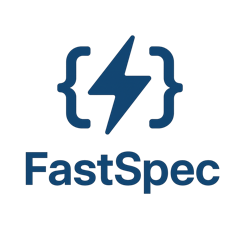

In [ ]:
resp = await cli.images.create_image(
    prompt="A clean, modern logo for 'FastSpec' — a developer tool that dynamically generates API clients from OpenAPI specs. Use a lightning bolt integrated with curly braces {}. Minimal, flat design, tech aesthetic, blue and white color scheme.",
    model="gpt-image-1",
    size="1024x1024",
    output_format="png",
    background="transparent"
)
img_data = resp['data'][0]['b64_json']
Path("fastspec_logo.png").write_bytes(base64.b64decode(img_data))
Image.open("fastspec_logo.png").resize((240,240))

In [ ]:
allow({OpFunc: ['__call__']})

I think it might make them all available this way, give it a go

I don't have an idea yet

Full API access:

In [ ]:
allow({OpGroup: [...], OpFunc: ['__call__']})

.

Ok let's see how we can allow only a specific group like `cli.images`

First let's disallow the previous setting

In [ ]:
__pytools__[OpGroup], __pytools__[OpFunc]

({Ellipsis}, {'__call__'})

In [ ]:
__pytools__[OpGroup].discard(...)
__pytools__[OpFunc].discard('__call__')

In [ ]:
__pytools__[OpGroup], __pytools__[OpFunc]

(set(), set())

Group access:

In [ ]:
allow({cli.images: [...], OpFunc: ['__call__']})

.

In [ ]:
__pytools__[cli.images], __pytools__[OpFunc]

({Ellipsis}, {'__call__'})

In [ ]:
__pytools__[cli.images].discard(...)
__pytools__[OpFunc].discard('__call__')

In [ ]:
__pytools__[cli.images], __pytools__[OpFunc]

(set(), set())

Individual method access:

In [ ]:
allow({cli.images: ['create_image'], OpFunc: ['__call__']})

.

In [ ]:
for nm,g in cli.groups.items(): allow({g: ..., OpFunc: ['__call__']}); print(nm)

assistants
audio
batches
chat
completions
containers
conversations
embeddings
evals
files
fine_tuning
images
models
moderations
organization
projects
realtime
responses
threads
uploads
vector_stores
videos
skills
chatkit


In [ ]:
for nm,g in cli.groups.items(): allow({g: ..., OpFunc: ['__call__']})

## Export -

In [ ]:
#|hide
#|eval: false
import nbdev; nbdev.nbdev_export()